In [ ]:
# Ensure repository-root working directory after notebook relocation
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
repo_root = cwd
if not (repo_root / 'pyproject.toml').exists():
    for parent in [cwd, *cwd.parents]:
        if (parent / 'pyproject.toml').exists():
            repo_root = parent
            break
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print(f'Working directory: {repo_root}')


### Extract routes from ASKCOS (web) downloaded json files

1. **Route Generation**  
   - Go to the ASKCOS website.  
   - Run the *Route Generation* job.

2. **Clustering**  
   - Once route generation completes, start the clustering step.  
   - **Do not** click **View clusters** at this stage.

3. **Download Results**  
   - Click **Download Results → All trees**.  
   - Save the archive. Probably it will be named as treeResults.json

4. **Relocate Output**  
   - Extract/move the downloaded file into your pre‑generated input directory.
   - Rename it using the specified job ID so the pipeline can find it.

In [1]:
import json

input_file = f'./data/askcos_apatinib.json'

with open(input_file, 'r') as file:
    routes = json.load(file)


In [2]:
from cgr_clustering.askcos_converter import extract_clusters

lstm_clusters = extract_clusters(routes)

### Distribution of LSTM-based clusters

In [4]:
group_sizes = [len(routes_set) for routes_set in lstm_clusters.values()]
print('Number of clusters by LSTM model:', len(group_sizes))

Number of clusters by LSTM model: 28


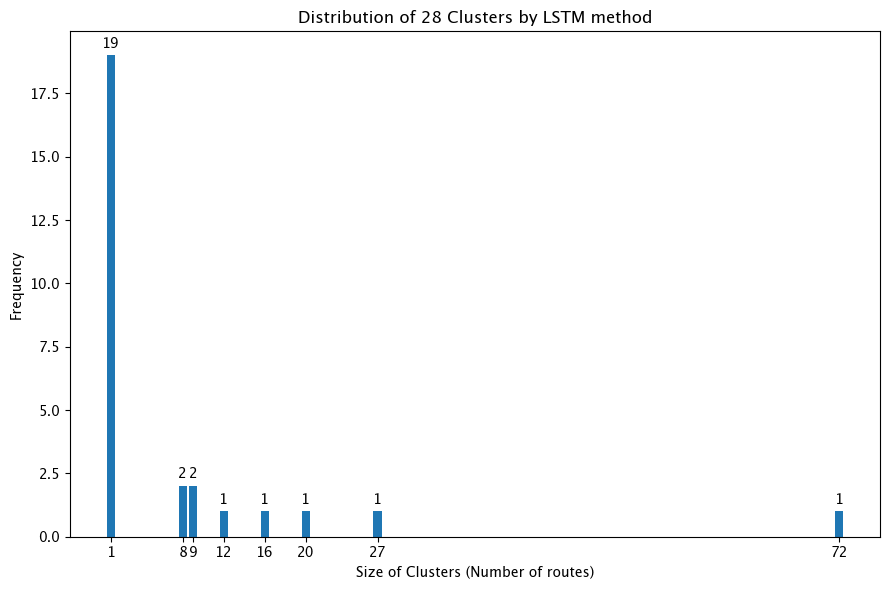

In [12]:
from cgr_clustering.visualization import plot_distribution

# plot_distribution(group_sizes, clusters)
plot_distribution(group_sizes, lstm_clusters, method='LSTM')

### Extract RouteCGR and SB-CGR

In [6]:
from cgr_clustering.askcos_converter import process_all_routes
from synplan.chem.reaction_routes.route_cgr import *
from cgr_clustering.sb_clustering import compose_all_sb_cgrs

/Users/almazgil/miniforge3-arm/envs/az_synplan_env/lib/python3.11/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
route_cgrs_dict = process_all_routes(routes)


200it [00:32,  6.22it/s]


In [8]:
sb_cgrs_dict = compose_all_sb_cgrs(route_cgrs_dict)

### SB-CGR Clustering

In [9]:
from synplan.chem.reaction_routes.clustering import cluster_routes
from cgr_clustering.sb_clustering import remap_final_cgrs

In [10]:
sb_groups = cluster_routes(sb_cgrs_dict)
smiles = str(sb_cgrs_dict[0].decompose()[1])
sbp_groups_n = remap_final_cgrs(sb_groups, smiles)
print("Number of SB groups:", len(sb_groups))

Number of SB groups: 10


In [11]:
from IPython.display import SVG, display

for group_index, group in sb_groups.items():
    print('group_index', group_index)
    sb_cgr = group['sb_cgr']
    sb_cgr.clean2d()
    display(SVG(sb_cgr.depict()))
    # print('strat_bonds', group['strat_bonds'])
    print()

group_index 1.1


strat_bonds [(17, 18)]

group_index 2.1


strat_bonds [(14, 15), (17, 18)]

group_index 2.2


strat_bonds [(11, 14), (17, 18)]

group_index 2.3


strat_bonds [(14, 15), (15, 30)]

group_index 3.1


strat_bonds [(14, 15), (15, 16), (17, 18)]

group_index 3.2


strat_bonds [(14, 15), (15, 16), (18, 19)]

group_index 4.1


strat_bonds [(14, 15), (15, 16), (15, 30), (17, 18)]

group_index 4.2


strat_bonds [(14, 15), (15, 16), (15, 30), (18, 19)]

group_index 4.3


strat_bonds [(14, 15), (15, 16), (17, 18), (19, 20)]

group_index 5.1


strat_bonds [(14, 15), (15, 16), (15, 30), (17, 18), (19, 20)]



### SB-CGR distribution

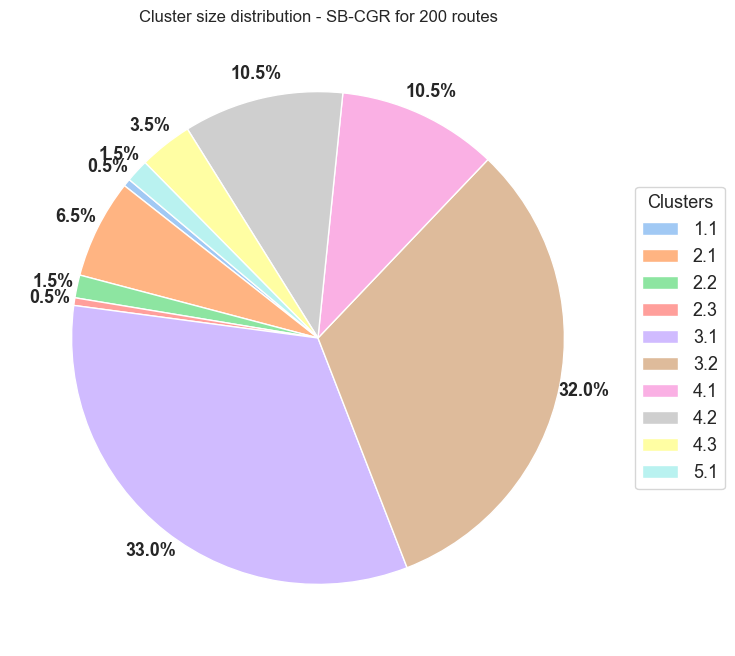

In [13]:
from cgr_clustering.visualization import plot_distribution

sb_cgr_group_sizes = [inner_dict.get('group_size', 0) for inner_dict in sb_groups.values()]

plot_distribution(sb_cgr_group_sizes, sb_groups, method='SB-CGR')

### Results overlaping Comparison

In [ ]:
from cgr_clustering.comparing import diagonalize_contingency, match_clusters, compute_contingency_matrix, calculate_similarity_metrics
from cgr_clustering.visualization import display_contingency_matrix

Adjusted Rand Index (ARI): 0.0727
Normalized Mutual Information (NMI): 0.3891
Entropy first: 1.6778
Entropy second: 2.2792
Mutual Information: 0.7699
Variation of Information (VI): 2.4172



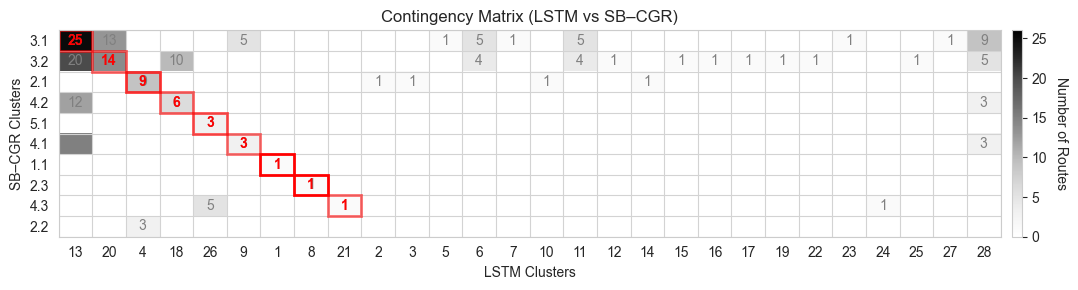

In [21]:
y_true, y_pred = calculate_similarity_metrics(sb_groups, lstm_clusters, print_stats=True)
cm = compute_contingency_matrix(y_true, y_pred)

matched, avg_jaccard = match_clusters(sb_groups, lstm_clusters)

cm_sorted, matches = diagonalize_contingency(cm)
display_contingency_matrix(matches, cm_sorted, method='LSTM')

### Extract the route_ids in ASKCOS by given cluster indices

Unfortunately, we can’t display ASKCOS results here, so you’ll need to use the ASKCOS website.

Use the following navigation rule:

- Find the row number and cluster index you were given (e.g., **row 13** and **cluster “3.1”**).
- On the ASKCOS results page, click **View clusters**.
- Go to the **13th cluster** in the list.
- Within that cluster, look at **only the pathways shown in the same order as in the results list**.

In [24]:
lstm_ind = 13
sb_cgr_ind = '3.1'

print('How the pathways are numbered in ASKCOS:', 
      np.array(contingency_nodes(sb_groups, lstm_clusters, sb_cgr_ind, lstm_ind)) - min(lstm_clusters[lstm_ind]) + 1 )

How the pathways are numbered in ASKCOS: [ 1  2  3  4  6 21 22 23 24 26 31 32 33 34 36 51 52 53 54 56 61 62 63 64
 66]


### For inter-comparison with other retorysnthteic tools' results (SynPlanner and AiZynthFinder)

In [ ]:
import pickle

pickle.dump(sb_groups, open('./inter_comp_data/askcos_clusters.pkl', 'wb'))